# Proyecciones financieras y análisis del desempeño actual y futuro de Apple Inc. en el mercado

*Informe de Equity Research · perspectiva de analista (nivel CFA).*

Este informe combina la información de los **Formularios 10-K (FY2025) y 10-Q (Q2-2026)**
de Apple con **datos públicos y recientes de fuentes de mercado** (Yahoo Finance,
stockanalysis.com, financecharts, Simply Wall St, S&P Global y BofA vía TheStreet). Los
datos de consenso corresponden al **23–24 de julio de 2026** y cambian continuamente; se
citan las fuentes al final. *Contenido educativo, no constituye recomendación de inversión.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# A) Calculado de los filings (10-K FY2025 / 10-Q Q2-2026)
# ============================================================
precio     = 333.02          # Yahoo Finance, cierre 24-jul-2026 (cerca de maximos historicos)
acciones_M = 14667.688       # 10-Q: acciones en circulacion (28-mar-2026), en millones
# UPA de los ultimos 12 meses (TTM) = FY2025 - H1 FY2025 + H1 FY2026
eps_ttm = 7.46 - 4.05 + 4.85          # = 8.26 (10-K y 10-Q, diluida)
div_anual = 0.26 * 4                  # dividendo trimestral 0.26 (10-Q) anualizado

mkt_cap = precio * acciones_M / 1e6            # USD billones (millones de millones = trillion)
pe_trailing = precio / eps_ttm
div_yield = div_anual / precio

# ============================================================
# B) Datos de mercado externos (fuentes citadas; 23-24 jul 2026)
# ============================================================
wk52_low, wk52_high = 201.50, 334.98   # financecharts / stockanalysis
ytd_ret, ret_1y = 0.2276, 0.5246       # financecharts (rendimiento total)
pt_avg, pt_low, pt_high = 318.81, 215.00, 400.00   # S&P Global / stockanalysis (47 analistas)
n_analistas = 47
fwd_pe = 38.0                          # stockanalysis (FY2026E)
eps_fy26_cons = 8.9                    # consenso FY2026E (~8.76-8.95)

print(f"Capitalizacion de mercado:  US$ {mkt_cap:.2f} billones")
print(f"UPA TTM (diluida):          US$ {eps_ttm:.2f}")
print(f"P/E trailing:               {pe_trailing:.1f}x")
print(f"P/E forward (FY2026E):      {fwd_pe:.1f}x")
print(f"Rendimiento por dividendo:  {div_yield*100:.2f}%")
print(f"Potencial al objetivo prom: {(pt_avg/precio-1)*100:+.1f}%  (rango {(pt_low/precio-1)*100:+.0f}% a {(pt_high/precio-1)*100:+.0f}%)")

Capitalizacion de mercado:  US$ 4.88 billones
UPA TTM (diluida):          US$ 8.26
P/E trailing:               40.3x
P/E forward (FY2026E):      38.0x
Rendimiento por dividendo:  0.31%
Potencial al objetivo prom: -4.3%  (rango -35% a +20%)


## 1. Desempeño actual de Apple en el mercado

Al **24 de julio de 2026** la acción cotiza cerca de **USD 333**, en la zona de sus
**máximos históricos** (cierre récord de USD 333.74 el 17-jul-2026; rango de 52 semanas
USD 201.50–334.98). El desempeño reciente ha sido muy fuerte: **+22.8 % en lo que va de
2026** y **+52 % en los últimos 12 meses**, con una **capitalización de mercado de ~USD 4.9
billones** [financecharts, Yahoo Finance].

**Los múltiplos son exigentes.** Con una UPA de los últimos doce meses de **~USD 8.26**
(calculada del 10-K/10-Q), el **P/E *trailing* es ~40x** y el **P/E *forward* ~38x**
[stockanalysis] — muy por encima del promedio histórico de Apple (~25–30x) y elevado frente
a un crecimiento de utilidades esperado de ~10 % anual (PEG ≈ 3.8). El **rendimiento por
dividendo es de apenas ~0.3 %**. En síntesis, la percepción del mercado es de **fuerte
optimismo —impulsado por la IA (*Apple Intelligence*) y el crecimiento de Servicios— pero
con la acción ya cotizando cara**, por encima incluso del precio objetivo promedio de los
analistas (ver Sección 3).

In [2]:
# Tabla de indicadores bursatiles
kpis = pd.DataFrame([
    ("Precio (24-jul-2026)", f"US$ {precio:,.2f}"),
    ("Rango 52 semanas", f"US$ {wk52_low:,.2f} - {wk52_high:,.2f}"),
    ("Rendimiento YTD 2026", f"{ytd_ret*100:+.1f}%"),
    ("Rendimiento 12 meses", f"{ret_1y*100:+.1f}%"),
    ("Capitalizacion de mercado", f"US$ {mkt_cap:.2f} billones"),
    ("UPA TTM (diluida)", f"US$ {eps_ttm:.2f}"),
    ("P/E trailing", f"{pe_trailing:.1f}x"),
    ("P/E forward (FY2026E)", f"{fwd_pe:.1f}x"),
    ("Rendimiento por dividendo", f"{div_yield*100:.2f}%"),
], columns=["Indicador bursátil", "Valor"])
kpis

,Indicador bursátil,Valor
0,Precio (24-jul-2026),US$ 333.02
1,Rango 52 semanas,US$ 201.50 - 334.98
2,Rendimiento YTD 2026,+22.8%
3,Rendimiento 12 meses,+52.5%
4,Capitalizacion de mercado,US$ 4.88 billones
5,UPA TTM (diluida),US$ 8.26
6,P/E trailing,40.3x
7,P/E forward (FY2026E),38.0x
8,Rendimiento por dividendo,0.31%


## 2. Proyecciones financieras (consenso de analistas)

La tabla combina los resultados **reales** del 10-K (FY2025) con las **estimaciones de
consenso** para los próximos años. Existe **dispersión entre fuentes**, sobre todo en
ingresos; se indica el valor central y, cuando aplica, se marca como aproximado o estimado.

In [3]:
# Proyecciones: real FY2025 + consenso FY2026-2028. Cifras en US$ mil M salvo EPS.
proj = pd.DataFrame({
    "Métrica": ["Ingresos (US$ mil M)", "Utilidad neta (US$ mil M)",
                "EPS diluido (US$)", "Flujo de caja libre (US$ mil M)"],
    "FY2025 (real)": ["416.2", "112.0", "7.46", "98.8"],
    "FY2026E": ["478.7", "131.5", "8.9", "141.0"],
    "FY2027E": ["~515", "146.0", "9.94", "~150"],
    "FY2028E": ["~550*", "163.1", "~11.5", "~165*"],
    "Fuente": ["stockanalysis / consenso", "Simply Wall St (50 analistas)",
               "stockanalysis / consenso", "stockanalysis (FY26); est."],
})
proj

,Métrica,FY2025 (real),FY2026E,FY2027E,FY2028E,Fuente
0,Ingresos (US$ mil M),416.2,478.7,~515,~550*,stockanalysis / consenso
1,Utilidad neta (US$ mil M),112.0,131.5,146.0,163.1,Simply Wall St (50 analistas)
2,EPS diluido (US$),7.46,8.9,9.94,~11.5,stockanalysis / consenso
3,Flujo de caja libre (US$ mil M),98.8,141.0,~150,~165*,stockanalysis (FY26); est.


**Lectura de las proyecciones.**

- **Ingresos:** el consenso apunta a ~USD 479 mil M en FY2026 (con estimaciones que van de
  ~USD 453 a 479 mil M según la fuente) y a superar los USD 500 mil M en FY2027 (BofA proyecta
  USD 523 mil M) [stockanalysis, TheStreet]. Crecimiento esperado de dígito medio-alto.
- **Utilidad neta:** 50 analistas proyectan **USD 131.5 / 146.0 / 163.1 mil M** para
  FY2026/27/28 [Simply Wall St], un crecimiento anual compuesto cercano al **10 %**.
- **EPS:** ~USD 8.9 (FY2026) y USD 9.94 (FY2027) de consenso; las **recompras** amplifican el
  crecimiento del EPS por encima del de la utilidad neta.
- **FCF:** ~USD 141 mil M en FY2026 [stockanalysis], un fuerte rebote frente a los USD 98.8 mil M
  de FY2025 —que estuvieron deprimidos por el pago único de impuestos en efectivo (USD 43.4
  mil M) documentado en el 10-K—.
- (\*) Los valores de FY2028 para ingresos y FCF son **extrapolaciones** propias a partir de la
  tendencia de consenso; el resto son cifras reportadas por las fuentes citadas.

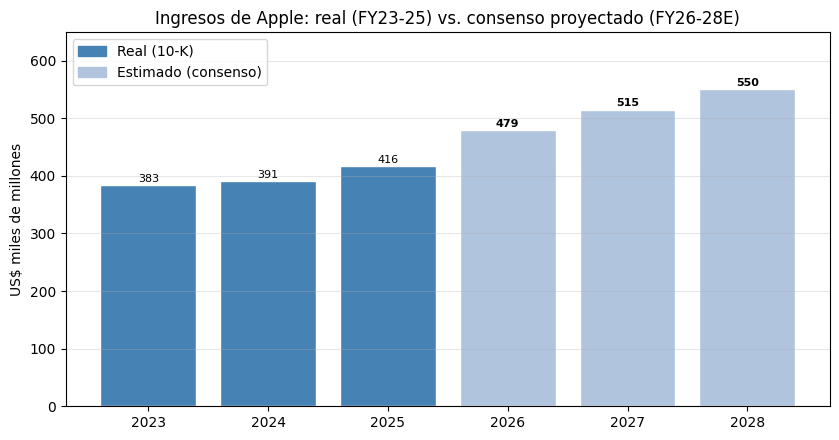

In [4]:
# Grafico A: Ingresos historicos (real) y proyectados (consenso)
anios = [2023, 2024, 2025, 2026, 2027, 2028]
rev = [383.3, 391.0, 416.2, 478.7, 515.0, 550.0]
real = [True, True, True, False, False, False]
colores = ["steelblue" if r else "lightsteelblue" for r in real]
fig, ax = plt.subplots(figsize=(8.5,4.5))
barras = ax.bar([str(a) for a in anios], rev, color=colores, edgecolor="white")
for a, v, r in zip(anios, rev, real):
    ax.text(str(a), v+6, f"{v:.0f}", ha="center", fontsize=8,
            fontweight=("bold" if not r else "normal"))
ax.set_title("Ingresos de Apple: real (FY23-25) vs. consenso proyectado (FY26-28E)")
ax.set_ylabel("US$ miles de millones"); ax.margins(y=0.18); ax.grid(axis="y", alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Real (10-K)"),
                   Patch(color="lightsteelblue", label="Estimado (consenso)")])
plt.tight_layout(); plt.show()

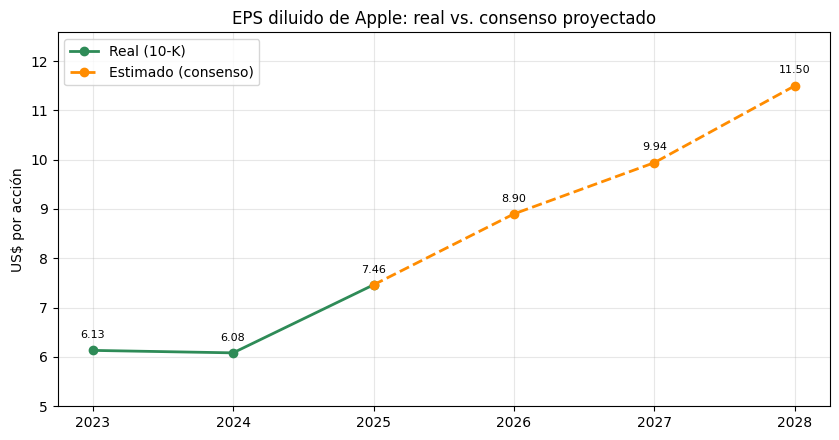

In [5]:
# Grafico B: EPS diluido historico y proyectado
eps = [6.13, 6.08, 7.46, 8.9, 9.94, 11.5]
fig, ax = plt.subplots(figsize=(8.5,4.5))
ax.plot(anios[:3], eps[:3], marker="o", lw=2, color="seagreen", label="Real (10-K)")
ax.plot(anios[2:], eps[2:], marker="o", lw=2, ls="--", color="darkorange", label="Estimado (consenso)")
for a, v in zip(anios, eps):
    ax.text(a, v+0.25, f"{v:.2f}", ha="center", fontsize=8)
ax.set_title("EPS diluido de Apple: real vs. consenso proyectado")
ax.set_xticks(anios); ax.set_ylabel("US$ por acción"); ax.margins(y=0.2)
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

## 3. Expectativas del mercado (analistas)

El consenso de **47 analistas** califica a Apple como **"Comprar"**: **60 % buy o strong buy,
34 % hold y 6 % sell** [S&P Global / stockanalysis]. Sin embargo —y esto es lo más relevante—
el **precio objetivo promedio es USD 318.81, aproximadamente 4 % POR DEBAJO del precio actual
(~USD 333)**, con un rango de USD 215 (−35 %) a USD 400 (+20 %).

La señal es clara: los analistas mantienen la calificación de compra por la **calidad del
negocio**, pero sus valuaciones objetivo **ya no ven potencial alcista significativo a 12
meses** —la acción se ha adelantado a sus precios objetivo—. Es una postura de "gran empresa,
pero cara al precio de hoy".

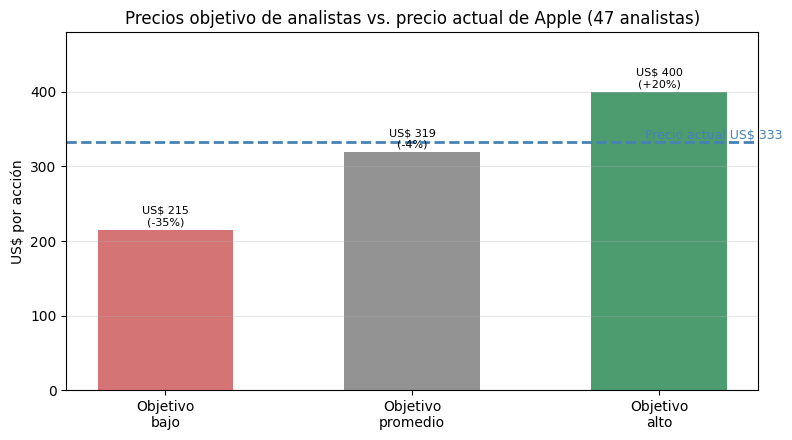

In [6]:
# Grafico C: Precio actual vs precios objetivo de los analistas
etiquetas = ["Objetivo\nbajo", "Objetivo\npromedio", "Objetivo\nalto"]
valores = [pt_low, pt_avg, pt_high]
fig, ax = plt.subplots(figsize=(8,4.5))
barras = ax.bar(etiquetas, valores, color=["indianred","gray","seagreen"], alpha=0.85, width=0.55)
for e, v in zip(etiquetas, valores):
    ax.text(e, v+6, f"US$ {v:.0f}\n({(v/precio-1)*100:+.0f}%)", ha="center", fontsize=8)
ax.axhline(precio, color="steelblue", lw=2, ls="--")
ax.text(2.5, precio+4, f"Precio actual US$ {precio:.0f}", ha="right", color="steelblue", fontsize=9)
ax.set_title("Precios objetivo de analistas vs. precio actual de Apple (47 analistas)")
ax.set_ylabel("US$ por acción"); ax.margins(y=0.2); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

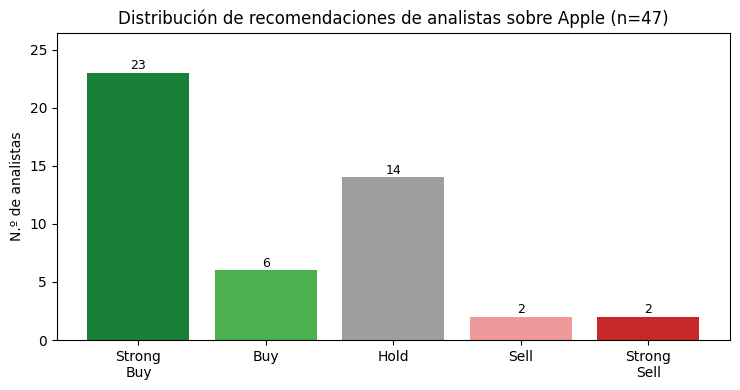

In [7]:
# Grafico D: Distribucion de recomendaciones
rating = {"Strong\nBuy":23, "Buy":6, "Hold":14, "Sell":2, "Strong\nSell":2}
cols = ["#1a7f37","#4caf50","#9e9e9e","#ef9a9a","#c62828"]
fig, ax = plt.subplots(figsize=(7.5,4))
b = ax.bar(list(rating.keys()), list(rating.values()), color=cols)
for k,v in rating.items(): ax.text(k, v+0.3, str(v), ha="center", fontsize=9)
ax.set_title("Distribución de recomendaciones de analistas sobre Apple (n=47)")
ax.set_ylabel("N.º de analistas"); ax.margins(y=0.15)
plt.tight_layout(); plt.show()

## 4. Impulsores de crecimiento y riesgos

**Impulsores del crecimiento futuro:**

- **Servicios:** el segmento de mayor margen crece a doble dígito (+13.5 % en FY2025, 10-K) y
  es recurrente; sostiene la expansión de márgenes y justifica parte de la prima de valuación.
- **Inteligencia artificial (*Apple Intelligence*):** potencial catalizador de un **superciclo
  de actualización del iPhone** y de nuevos servicios; las fuentes señalan un aumento de CapEx
  (~+35 % hacia 2027) para infraestructura de datos e IA.
- **Base instalada** de más de 2,300 millones de dispositivos que Apple monetiza vía servicios.
- **Retorno de capital:** el programa de recompras de **USD 100 mil M** (10-K) reduce las
  acciones y potencia el EPS.
- **Mercados emergentes** (India) y nuevas categorías de producto.

**Principales riesgos para las proyecciones:**

- **Valuación exigente:** a ~38x utilidades *forward* y con el precio por encima del objetivo
  promedio, hay poco margen de error; cualquier decepción puede corregir el múltiplo.
- **Concentración en el iPhone** y sensibilidad del ciclo de reemplazo.
- **Regulatorio/antimonopolio:** App Store, DMA europea y litigios en EE. UU. amenazan los
  ingresos de Servicios, de alto margen (10-K, Item 1A).
- **China y cadena de suministro:** exposición de ventas y **concentración de proveedores en
  Asia** (10-K); tensiones comerciales y arancelarias.
- **Tipo de cambio** (dólar fuerte) y **ejecución en IA**, donde Apple es percibida como
  rezagada frente a sus pares.

## 5. Interpretación de resultados

**¿Son favorables las perspectivas de Apple?** Sí en el largo plazo. El negocio es dominante y
extraordinariamente rentable (margen operativo 32 %, ROIC ~65 %, ~USD 99 mil M de flujo libre
en FY2025), con Servicios de alto margen en expansión, una IA que puede reactivar el ciclo del
iPhone y un potente programa de retorno de capital. El consenso proyecta un crecimiento de
utilidades cercano al **10 % anual** y una utilidad neta que pasaría de USD 112 a ~USD 163 mil M
entre FY2025 y FY2028.

**¿Son las expectativas del mercado consistentes con los fundamentos del 10-K/10-Q?** Solo en
parte. Los estados financieros describen una empresa **excelente pero de crecimiento moderado**
(ingresos +6.4 % y utilidad operativa +8 % en FY2025). El mercado, en cambio, paga **~38x
utilidades *forward* y ~USD 4.9 billones de capitalización**, un múltiplo que **descuenta una
aceleración** (superciclo de IA y Servicios) que **todavía no está plenamente reflejada en las
cifras reportadas**. El propio consenso de analistas captura esta tensión: mantiene calificación
de **"Comprar" por calidad**, pero fija un **precio objetivo promedio ~4 % por debajo del precio
de mercado**, señal de que la acción se ha adelantado a su valor razonable estimado.

**Balance final:** fundamentos sólidos y perspectivas favorables, pero **valuación exigente**.
El atractivo de Apple como *negocio* es incuestionable; su atractivo como *acción al precio
actual* es más discutible: el potencial alcista a 12 meses luce limitado y la acción es
vulnerable a decepciones en iPhone, regulación o ejecución en IA. Para el inversionista de largo
plazo, una compañía de altísima calidad; para el de corto plazo, un punto de entrada caro que
conviene vigilar.

## Fuentes

- Apple Inc. — Formulario **10-K FY2025** y **10-Q Q2-2026** (datos financieros y de la acción calculados).
- [stockanalysis.com — AAPL Forecast](https://stockanalysis.com/stocks/aapl/forecast/) (consenso de ingresos, EPS y FCF FY2026, precio objetivo, recomendaciones y P/E forward).
- [Simply Wall St — AAPL Future](https://simplywall.st/stocks/us/tech/nasdaq-aapl/apple/future) (proyecciones de utilidad neta FY2026-2028, 50 analistas).
- [financecharts — AAPL](https://www.financecharts.com/stocks/AAPL/summary/price) (rango 52 semanas, rendimiento YTD y 12 meses, capitalización).
- [TheStreet — BofA sobre Apple](https://www.thestreet.com/investing/stocks/bank-of-america-sends-clear-message-on-apple-stock-before-earnings) (estimaciones de ingresos y EPS FY2026-2027 de BofA).
- [WallStreetZen — AAPL Forecast](https://www.wallstreetzen.com/stocks/us/nasdaq/aapl/stock-forecast) y Yahoo Finance (precio y contexto de mercado).

*Datos de consenso al 23–24 de julio de 2026; las estimaciones de analistas se actualizan de forma continua.*